En este notebook, abordaremos el desafío de construir un modelo tarifario actuarial. Nuestro objetivo principal es determinar la prima pura de riesgo para seguros de automóviles, considerando la heterogeneidad de los riesgos asociados. Utilizaremos variables demográficas, geográficas y del vehículo para modelar la frecuencia y la severidad de los siniestros de manera independiente, utilizando Modelos Lineales Generalizados (GLM).

# **1. Planteamiento del Problema**
Objetivo: Desarrollar un modelo tarifario actuarial para determinar la prima pura de riesgo.

Justificación: El uso de promedios simples ignora la heterogeneidad del riesgo. Necesitamos modelos que capturen la probabilidad de ocurrencia (frecuencia) y el impacto económico (severidad) de forma separada.

Variables clave: Identificar cómo influyen factores demográficos (DrivAge), geográficos (Area, Density) y del vehículo (VehPower, VehAge) en el riesgo.

## **2. Carga y Preprocesamiento de Datos**

Esta sección se encarga de cargar los datos de frecuencia y severidad, que provienen de conjuntos de datos comúnmente utilizados en seguros de automóviles en Francia (FreMTPL2). Posteriormente, se realizan los siguientes pasos de preprocesamiento:

1.  **Carga de Datos:** Se cargan `freMTPL2freq.csv` (para las características de las pólizas y la frecuencia de siniestros) y `freMTPL2sev.csv` (para los montos de los siniestros).
2.  **Agregación de Severidad:** Se agrupan los montos de los siniestros por `IDpol` para obtener el `Monto_Total` y el `Num_Siniestros_Sev` por cada póliza.
3.  **Unión de Datos (Merge):** Se combinan los datos de frecuencia y severidad utilizando `IDpol` como clave. Se usa un `left merge` para asegurar que todas las pólizas de `df_freq` se mantengan, incluso aquellas sin siniestros.
4.  **Tratamiento de Nulos:** Las pólizas que no tuvieron siniestros (y por lo tanto no aparecen en `df_sev`) tendrán `NaN` en `Monto_Total` y `Num_Siniestros_Sev`. Estos se imputan a 0.
5.  **Consistencia de Siniestros:** Se ajusta la columna `ClaimNb` (número de siniestros reportados) para que sea consistente con `Num_Siniestros_Sev` (siniestros del archivo de severidad), tomando el valor máximo entre ambos para evitar subestimaciones.
6.  **Tratamiento de Outliers (Capping):** Se aplica un *capping* al `Monto_Total` en el percentil 99 para mitigar el impacto de valores extremos que pueden sesgar los modelos GLM.
7.  **Filtrado de Exposición:** Se eliminan las pólizas con `Exposure` (tiempo de exposición al riesgo) menor o igual a 0, y `Monto_Total` negativos, ya que son datos inconsistentes.

In [8]:
import pandas as pd
import numpy as np

# 1. CARGA DE DATOS
# Cargamos frecuencia (características) y severidad (montos)
df_freq = pd.read_csv('freMTPL2freq.csv')
df_sev = pd.read_csv('freMTPL2sev.csv')

# 2. AGREGACIÓN DE SEVERIDAD
# Sumamos los montos por IDpol para tener el costo total por riesgo.
df_sev_agg = df_sev.groupby('IDpol').agg(
    Monto_Total=('ClaimAmount', 'sum'),
    Num_Siniestros_Sev=('ClaimAmount', 'count')
).reset_index()

# 3. MERGE
# Usamos 'left' para conservar todas las pólizas, incluso las que no chocaron.
df_master = pd.merge(df_freq, df_sev_agg, on='IDpol', how='left')

# 4. TRATAMIENTO DE NULOS
# Las pólizas sin registro en la tabla de severidad tienen un monto de 0.
df_master['Monto_Total'] = df_master['Monto_Total'].fillna(0)
df_master['Num_Siniestros_Sev'] = df_master['Num_Siniestros_Sev'].fillna(0)

# 5. CONSISTENCIA (Data Quality)
# Ajustamos ClaimNb para que sea el máximo entre ambos y evitar subestimar.
df_master['ClaimNb'] = df_master[['ClaimNb', 'Num_Siniestros_Sev']].max(axis=1)

# 6. TRATAMIENTO DE OUTLIERS (Capping)
# Siniestros exagerados pueden sesgar los GLM. Capamos al percentil 99.
p99 = df_master[df_master['Monto_Total'] > 0]['Monto_Total'].quantile(0.99)
df_master['Monto_Capped'] = df_master['Monto_Total'].clip(upper=p99)

# 7. FILTRADO DE EXPOSICIÓN
# Eliminamos pólizas con exposición <= 0 o montos negativos (errores de captura).
df_master = df_master[(df_master['Exposure'] > 0) & (df_master['Monto_Total'] >= 0)]

print(f"Tamaño dataset: {df_master.shape}")
df_master.head()

Tamaño dataset: (678013, 15)


,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region,Monto_Total,Num_Siniestros_Sev,Monto_Capped
0,1.0,1.0,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,0.0,0.0,0.0
1,3.0,1.0,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,0.0,0.0,0.0
2,5.0,1.0,0.75,6,2,52,50,B12,Diesel,B,54,Picardie,0.0,0.0,0.0
3,10.0,1.0,0.09,7,0,46,50,B12,Diesel,B,76,Aquitaine,0.0,0.0,0.0
4,11.0,1.0,0.84,7,0,46,50,B12,Diesel,B,76,Aquitaine,0.0,0.0,0.0


## **3. Exploración de Datos (EDA)**

En esta sección, se realiza un análisis exploratorio de datos (EDA) para entender las distribuciones de las variables de respuesta (frecuencia y severidad) y su relación con las variables explicativas.

1.  **Distribución de Severidad:** Se visualiza la distribución del `Monto_Total` de los siniestros, tanto en su escala original como en escala logarítmica, para identificar su forma y la presencia de asimetría o valores atípicos.
2.  **Frecuencia por Edad del Conductor (`DrivAge`):** Se calcula la frecuencia observada (siniestros / exposición) por cada grupo de edad del conductor y se grafica para observar cómo varía la propensión a tener siniestros con la edad.
3.  **Frecuencia por Zona Geográfica (`Area`):** Se analiza la frecuencia observada por cada zona geográfica para identificar posibles diferencias en el riesgo entre distintas regiones.

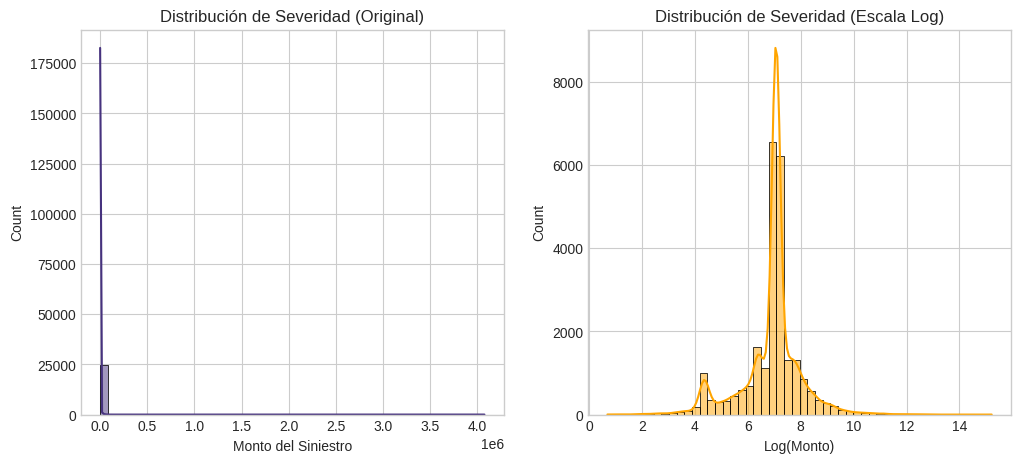

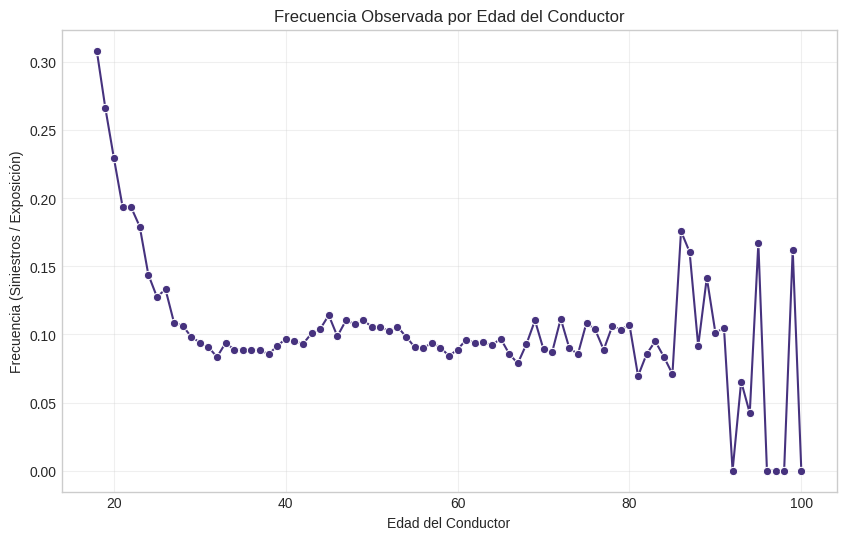

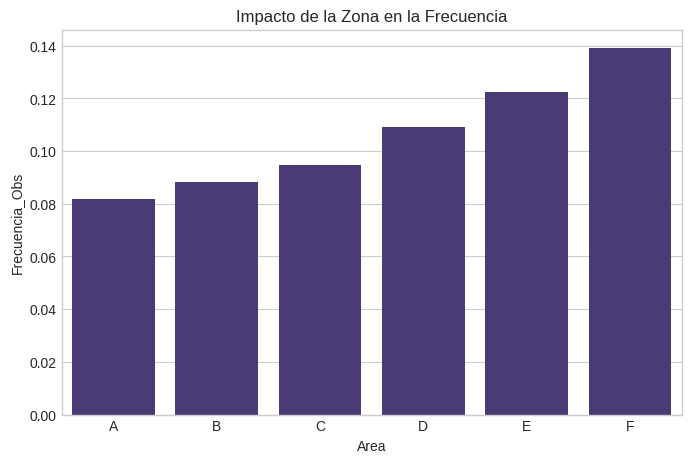

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# 1. ANÁLISIS DE LA VARIABLE RESPUESTA: SEVERIDAD
# Filtramos solo pólizas con siniestro para ver la distribución de severidad
df_sev_only = df_master[df_master['Monto_Total'] > 0]

plt.figure(figsize=(12, 5))

# Histograma de Severidad (en escala logarítmica para ver mejor la forma)
plt.subplot(1, 2, 1)
sns.histplot(df_sev_only['Monto_Total'], kde=True, bins=50)
plt.title('Distribución de Severidad (Original)')
plt.xlabel('Monto del Siniestro')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df_sev_only['Monto_Total']), kde=True, bins=50, color='orange')
plt.title('Distribución de Severidad (Escala Log)')
plt.xlabel('Log(Monto)')
plt.show()

# 2. ANÁLISIS DE FRECUENCIA POR EDAD
# Agrupamos por edad del conductor y calculamos la frecuencia observada
# Frecuencia = Siniestros / Exposición
age_profile = df_master.groupby('DrivAge').agg(
    Total_Siniestros=('ClaimNb', 'sum'),
    Total_Exposicion=('Exposure', 'sum')
).reset_index()

age_profile['Frecuencia_Obs'] = age_profile['Total_Siniestros'] / age_profile['Total_Exposicion']

plt.figure(figsize=(10, 6))
sns.lineplot(data=age_profile, x='DrivAge', y='Frecuencia_Obs', marker='o')
plt.title('Frecuencia Observada por Edad del Conductor')
plt.xlabel('Edad del Conductor')
plt.ylabel('Frecuencia (Siniestros / Exposición)')
plt.grid(True, alpha=0.3)
plt.show()

# 3. ANÁLISIS POR ZONA (Variable Categórica)
area_profile = df_master.groupby('Area').agg(
    Frecuencia_Obs=('ClaimNb', 'sum'),
    Exposicion=('Exposure', 'sum')
).reset_index()
area_profile['Frecuencia_Obs'] = area_profile['Frecuencia_Obs'] / area_profile['Exposicion']

plt.figure(figsize=(8, 5))
sns.barplot(data=area_profile, x='Area', y='Frecuencia_Obs')
plt.title('Impacto de la Zona en la Frecuencia')
plt.show()

## **4. Modelado Actuarial con GLM**

Esta sección implementa los Modelos Lineales Generalizados (GLM) para modelar la frecuencia y la severidad de los siniestros de manera independiente, utilizando las variables preprocesadas.

1.  **Modelo de Frecuencia (Poisson):**
    *   Se utiliza una distribución de Poisson con función de enlace logarítmica para modelar el número de siniestros (`ClaimNb`).
    *   La exposición (`Exposure`) se incorpora como un `offset` (con su logaritmo) en el modelo, ya que el número de siniestros es proporcional a la exposición.
    *   Las variables explicativas (`Area`, `VehPower`, `VehGas`, `DrivAge`, `VehAge`, `Density`) se usan para predecir la frecuencia.
2.  **Modelo de Severidad (Gamma):**
    *   Se utiliza una distribución Gamma con función de enlace logarítmica para modelar la severidad de los siniestros (`Monto_Total`).
    *   Este modelo se entrena **solo con las pólizas que tuvieron siniestros** (donde `Monto_Total` > 0).
    *   Las variables explicativas (`Area`, `VehPower`, `VehGas`, `DrivAge`, `VehAge`) se usan para predecir la severidad.
3.  **Cálculo de la Prima Pura Predicha:**
    *   Una vez entrenados ambos modelos, se utilizan para predecir la frecuencia y la severidad para cada póliza.
    *   La **Prima Pura Predicha** se calcula como el producto de la `Frecuencia_Predicha` y la `Severidad_Predicha` (`Prima_Pura_Pred = Freq_Pred * Sev_Pred`). Este es el costo técnico esperado por póliza.

In [10]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

# 1. MODELO DE FRECUENCIA (Poisson)
# Usamos log(Exposure) como offset porque la frecuencia es Siniestros/Exposición
df_master['log_exposure'] = np.log(df_master['Exposure'])

formula_freq = "ClaimNb ~ Area + VehPower + VehGas + DrivAge + VehAge + Density"

model_freq = smf.glm(formula=formula_freq,
                     data=df_master,
                     family=sm.families.Poisson(),
                     offset=df_master['log_exposure']).fit()

print("--- RESUMEN MODELO FRECUENCIA ---")
print(model_freq.summary())


# 2. MODELO DE SEVERIDAD INICIAL (Gamma)
# Solo entrenamos con las pólizas que SÍ tuvieron siniestro
df_sev_train_initial = df_master[df_master['Monto_Total'] > 0].copy()

formula_sev_initial = "Monto_Total ~ Area + VehPower + VehGas + DrivAge + VehAge" # Sin C(Decil_Riesgo)

model_sev_initial = smf.glm(formula=formula_sev_initial,
                            data=df_sev_train_initial,
                            family=sm.families.Gamma(link=sm.families.links.Log())).fit()

# 3. CÁLCULO DE LA PRIMA PURA PREDICHA INICIAL para definir Decil_Riesgo
# Predicción de Frecuencia
df_master['Freq_Pred_initial'] = model_freq.predict(df_master) / df_master['Exposure']

# Predicción de Severidad inicial
df_master['Sev_Pred_initial'] = model_sev_initial.predict(df_master)

# Prima Pura Inicial = Frecuencia * Severidad inicial
df_master['Prima_Pura_Pred_initial'] = df_master['Freq_Pred_initial'] * df_master['Sev_Pred_initial']

# Definimos Decil_Riesgo con la prima pura inicial
df_master['Decil_Riesgo'] = pd.qcut(df_master['Prima_Pura_Pred_initial'], 10, labels=False, duplicates='drop')


# 4. MODELO DE SEVERIDAD FINAL (Gamma) - CON Decil_Riesgo
df_sev_train_final = df_master[df_master['Monto_Total'] > 0].copy()

formula_sev_final = "Monto_Total ~ Area + VehPower + VehGas + DrivAge + VehAge + C(Decil_Riesgo)"

model_sev_final = smf.glm(formula=formula_sev_final,
                          data=df_sev_train_final,
                          family=sm.families.Gamma(link=sm.families.links.Log())).fit()

print("\n--- RESUMEN MODELO SEVERIDAD ---")
print(model_sev_final.summary())

# 5. CÁLCULO DE LA PRIMA PURA PREDICHA FINAL
# Predicción de Frecuencia (se usa el mismo model_freq)
df_master['Freq_Pred'] = model_freq.predict(df_master) / df_master['Exposure']

# Predicción de Severidad con el modelo FINAL
df_master['Sev_Pred'] = model_sev_final.predict(df_master)

# Prima Pura FINAL = Frecuencia * Severidad FINAL
df_master['Prima_Pura_Pred'] = df_master['Freq_Pred'] * df_master['Sev_Pred']

print("\n--- EJEMPLO DE TARIFACIÓN FINAL ---")
df_master.drop(columns=['Freq_Pred_initial', 'Sev_Pred_initial', 'Prima_Pura_Pred_initial'], inplace=True, errors='ignore')

print(df_master[['IDpol', 'Freq_Pred', 'Sev_Pred', 'Prima_Pura_Pred', 'Decil_Riesgo']].head())

--- RESUMEN MODELO FRECUENCIA ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               678013
Model:                            GLM   Df Residuals:                   678002
Model Family:                 Poisson   Df Model:                           10
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4569e+05
Date:                Fri, 08 May 2026   Deviance:                   2.2205e+05
Time:                        23:34:16   Pearson chi2:                 1.81e+06
No. Iterations:                     7   Pseudo R-squ. (CS):           0.003582
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Inte

### **5.1 Diagnóstico del Modelo de Frecuencia (Poisson)**

En esta subsección, profundizaremos en el diagnóstico del modelo de frecuencia Poisson, incorporando los métodos estadísticos solicitados para evaluar su ajuste y propiedades.

1.  **Estimación de \(\lambda\) por máxima verosimilitud:** Para una distribución de Poisson, el estimador de máxima verosimilitud de la media (\(\lambda\)) es simplemente la media muestral de las observaciones.
2.  **Intervalo de confianza 95% para \(\lambda\):** Calcularemos un intervalo de confianza para la tasa media de siniestros.\
3.  **Prueba Chi-cuadrada de bondad de ajuste:** Evaluaremos si el modelo Poisson se ajusta adecuadamente a la distribución observada del número de siniestros.
4.  **Prueba z para comparación de dos tasas:** Demostraremos cómo comparar la frecuencia de siniestros entre dos grupos, por ejemplo, diferentes áreas geográficas.

In [11]:
# 1. Estimación de lambda (lambda_hat) por máxima verosimilitud (media muestral)
# Para la distribución de Poisson, el MLE de lambda es la media muestral.
lambda_mle = df_master['ClaimNb'].mean()
print(f"Estimación de lambda (media muestral de ClaimNb): {lambda_mle:.4f}")

# 2. Intervalo de confianza 95% para lambda
# Usando la aproximación normal para la media de Poisson (para N grande)
import statsmodels.stats.api as sms

# Calculamos el intervalo de confianza para la media de ClaimNb
# La varianza de una Poisson es lambda, por lo que el error estándar es sqrt(lambda/N)
ci_lower, ci_upper = sms.DescrStatsW(df_master['ClaimNb']).tconfint_mean(alpha=0.05)

print(f"Intervalo de Confianza del 95% para lambda (media de ClaimNb): [{ci_lower:.4f}, {ci_upper:.4f}]")

Estimación de lambda (media muestral de ClaimNb): 0.0532
Intervalo de Confianza del 95% para lambda (media de ClaimNb): [0.0527, 0.0538]


In [12]:
# 3. Prueba Chi-cuadrada de bondad de ajuste
# Comparamos las frecuencias observadas de ClaimNb con las esperadas por el modelo Poisson.

# Obtener los recuentos observados de ClaimNb
observed_counts = df_master['ClaimNb'].value_counts().sort_index()

# Limitar a un número razonable de siniestros para la prueba (ej. hasta 5 o 6)
max_claim_nb_for_test = 5
observed_counts_filtered = observed_counts[observed_counts.index <= max_claim_nb_for_test]

# Para valores mayores, agrupamos en '5+'
if observed_counts.index.max() > max_claim_nb_for_test:
    observed_counts_filtered[f'>{max_claim_nb_for_test}'] = observed_counts[observed_counts.index > max_claim_nb_for_test].sum()

# Calcular los recuentos esperados bajo el modelo Poisson (usando lambda_mle)
from scipy.stats import poisson

expected_counts = pd.Series({
    i: poisson.pmf(i, lambda_mle) * len(df_master)
    for i in range(max_claim_nb_for_test + 1)
})

if observed_counts.index.max() > max_claim_nb_for_test:
    expected_counts[f'>{max_claim_nb_for_test}'] = (1 - poisson.cdf(max_claim_nb_for_test, lambda_mle)) * len(df_master)

# Ajustar los índices para que coincidan para la prueba
expected_counts = expected_counts.reindex(observed_counts_filtered.index, fill_value=0)

# Asegurarse de que no haya valores esperados muy pequeños (puede causar problemas con chi-cuadrado)
# Agrupar categorías si los recuentos esperados son < 5

# Realizar la prueba chi-cuadrada (usando scipy.stats.chi2_contingency o custom)
# Aquí una implementación simplificada para bondad de ajuste
from scipy.stats import chisquare

# Filtrar para asegurar que todos los recuentos esperados son > 0 (o agrupar)
# Para una prueba robusta, se recomienda agrupar si expected_counts < 5
# Por simplicidad, aquí usaremos los valores directos, pero se debe tener precaución.

# Asegurarse de que los tipos de datos son consistentes
observed_array = observed_counts_filtered.values.astype(float)
expected_array = expected_counts.values.astype(float)

# Filtramos pares donde expected_array sea 0 para evitar errores
valid_indices = expected_array > 0
observed_array = observed_array[valid_indices]
expected_array = expected_array[valid_indices]

if len(observed_array) > 1 and np.sum(expected_array) > 0:
    chi2_stat, p_value = chisquare(f_obs=observed_array, f_exp=expected_array)
    print(f"\nPrueba Chi-cuadrada de Bondad de Ajuste para ClaimNb:")
    print(f"  Estadístico Chi-cuadrado: {chi2_stat:.4f}")
    print(f"  P-valor: {p_value:.4f}")
    if p_value < 0.05:
        print("  El modelo Poisson no se ajusta bien a los datos (rechazamos H0).")
    else:
        print("  El modelo Poisson parece ajustarse bien a los datos (no rechazamos H0).")
else:
    print("No hay suficientes datos válidos para realizar la prueba chi-cuadrada de bondad de ajuste.")

print("\nRecuentos Observados:\n", observed_counts_filtered)
print("\nRecuentos Esperados (Modelo Poisson):\n", expected_counts)


Prueba Chi-cuadrada de Bondad de Ajuste para ClaimNb:
  Estadístico Chi-cuadrado: 2392862.8520
  P-valor: 0.0000
  El modelo Poisson no se ajusta bien a los datos (rechazamos H0).

Recuentos Observados:
 ClaimNb
0.0    643953
1.0     32178
2.0      1784
3.0        82
4.0         7
5.0         2
>5          7
Name: count, dtype: int64

Recuentos Esperados (Modelo Poisson):
 ClaimNb
0.0    642855.322571
1.0     34229.967354
2.0       911.317542
3.0        16.174904
4.0         0.215315
5.0         0.002293
>5          0.000021
dtype: float64


In [14]:
claims_A = df_master[df_master['Area'] == 'A']['ClaimNb'].sum()
exposure_A = df_master[df_master['Area'] == 'A']['Exposure'].sum()
rate_A = claims_A / exposure_A

# Datos para Área B
claims_B = df_master[df_master['Area'] == 'B']['ClaimNb'].sum()
exposure_B = df_master[df_master['Area'] == 'B']['Exposure'].sum()
rate_B = claims_B / exposure_B

print(f"Frecuencia en Área A: {rate_A:.4f}")
print(f"Frecuencia en Área B: {rate_B:.4f}")

# Calcular el error estándar combinado
se_pooled = np.sqrt(rate_A / exposure_A + rate_B / exposure_B)

# Calcular el estadístico Z
if se_pooled > 0:
    z_stat = (rate_A - rate_B) / se_pooled
    # Calcular el p-valor (prueba bilateral)
    from scipy.stats import norm
    p_value_z = 2 * (1 - norm.cdf(abs(z_stat)))

    print(f"\nPrueba Z para comparar tasas (Área A vs. Área B):")
    print(f"  Estadístico Z: {z_stat:.4f}")
    print(f"  P-valor: {p_value_z:.4f}")
    if p_value_z < 0.05:
        print("  Existe una diferencia estadísticamente significativa entre las tasas (rechazamos H0).")
    else:
        print("  No hay evidencia de una diferencia estadísticamente significativa entre las tasas (no rechazamos H0).")
else:
    print("No se puede calcular el error estándar (exposición insuficiente o tasas cero).")

Frecuencia en Área A: 0.0817
Frecuencia en Área B: 0.0883

Prueba Z para comparar tasas (Área A vs. Área B):
  Estadístico Z: -3.6185
  P-valor: 0.0003
  Existe una diferencia estadísticamente significativa entre las tasas (rechazamos H0).


In [16]:
# Extraer coeficientes de frecuencia
print("Coeficientes de Frecuencia (Top 5):")
print(model_freq.params.head())

# Extraer coeficientes de severidad
print("\nCoeficientes de Severidad (Top 5):")
print(model_sev_final.params.head())

Coeficientes de Frecuencia (Top 5):
Intercept   -2.026426
Area[T.B]    0.046808
Area[T.C]    0.095646
Area[T.D]    0.221206
Area[T.E]    0.288303
dtype: float64

Coeficientes de Severidad (Top 5):
Intercept    7.227267
Area[T.B]   -0.051630
Area[T.C]   -0.119758
Area[T.D]   -0.165827
Area[T.E]   -0.211711
dtype: float64


## **5. Validación y Análisis de Resultados**

Esta sección se enfoca en validar la capacidad predictiva del modelo y analizar la distribución de la prima pura calculada. Es crucial para asegurar que el modelo se comporta como se espera y que las primas asignadas son razonables y discriminan adecuadamente el riesgo.

1.  **Gráfica de Lift Chart (Observado vs Predicho):**
    *   Se divide la cartera en deciles (10 grupos) basados en la Prima Pura Predicha.
    *   Se compara la siniestralidad promedio observada en cada decil con la prima pura promedio predicha. Un modelo efectivo debería mostrar una correlación positiva, donde los deciles de mayor riesgo predicho también presenten una siniestralidad observada más alta.
    *   Esto permite verificar la capacidad de discriminación del modelo: ¿los asegurados clasificados como de mayor riesgo realmente tienen más siniestros y más costosos?
2.  **Distribución de la Prima Pura:**
    *   Se visualiza la distribución de la `Prima_Pura_Pred` en toda la cartera.
    *   Esto ayuda a entender el rango de primas, identificar posibles valores atípicos y asegurar que la distribución es coherente con las expectativas de negocio.

### Análisis de la baja siniestralidad en los deciles de riesgo 8 y 9

El `lift_df` muestra que la `Prima_Pura_Prom_Pred` aumenta drásticamente en los deciles 8 y 9, pero la `Siniestralidad_Prom_Obs` es sorprendentemente baja en comparación con los deciles intermedios. Esto sugiere un comportamiento atípico.

In [17]:
# Filtrar las pólizas en los deciles 8 y 9
deciles_8_9_df = df_master[df_master['Decil_Riesgo'].isin([8, 9])]

print(f"Número de pólizas en deciles 8 y 9: {len(deciles_8_9_df)}")

# Estadísticas descriptivas de las variables clave para estos deciles
print("\nEstadísticas descriptivas para deciles 8 y 9:")
print(deciles_8_9_df[['ClaimNb', 'Monto_Total', 'Exposure', 'Prima_Pura_Pred']].describe())

# Análisis de la frecuencia de siniestros en estos deciles
freq_deciles_8_9 = deciles_8_9_df['ClaimNb'].sum() / deciles_8_9_df['Exposure'].sum()
print(f"\nFrecuencia de siniestros en deciles 8 y 9: {freq_deciles_8_9:.4f}")

# Frecuencia global para comparación
freq_global = df_master['ClaimNb'].sum() / df_master['Exposure'].sum()
print(f"Frecuencia de siniestros en el dataset completo: {freq_global:.4f}")


Número de pólizas en deciles 8 y 9: 135603

Estadísticas descriptivas para deciles 8 y 9:
             ClaimNb    Monto_Total       Exposure  Prima_Pura_Pred
count  135603.000000  135603.000000  135603.000000    135603.000000
mean        0.030206      36.898078       0.065960     14251.099995
std         0.186059    1609.732539       0.036167     26156.333101
min         0.000000       0.000000       0.002732      1782.139155
25%         0.000000       0.000000       0.040000      4101.919962
50%         0.000000       0.000000       0.070000      5813.101221
75%         0.000000       0.000000       0.080000     11880.559584
max        11.000000  382955.140000       0.320000    251472.033989

Frecuencia de siniestros en deciles 8 y 9: 0.4579
Frecuencia de siniestros en el dataset completo: 0.1007


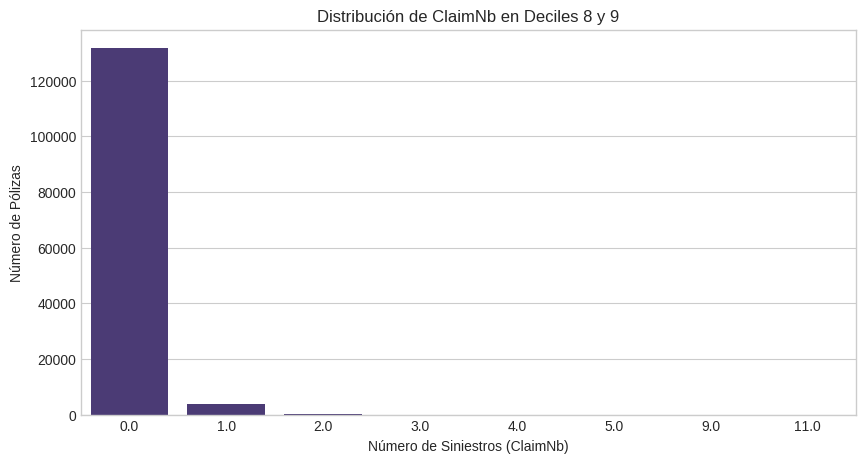

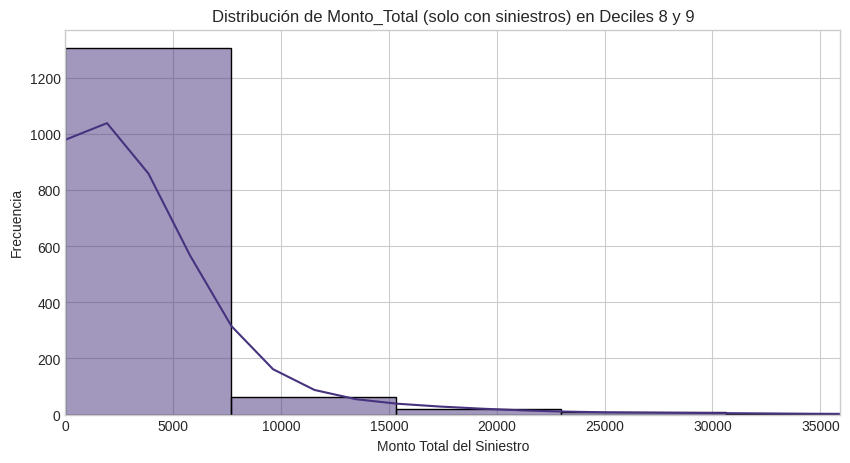


Características promedio de las pólizas en deciles 8 y 9 (variables explicativas):
Area              E
VehPower          7
VehGas      Regular
DrivAge          32
VehAge            0
Density        3317
Name: 0, dtype: object


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribución de ClaimNb en deciles 8 y 9
plt.figure(figsize=(10, 5))
sns.countplot(x='ClaimNb', data=deciles_8_9_df)
plt.title('Distribución de ClaimNb en Deciles 8 y 9')
plt.xlabel('Número de Siniestros (ClaimNb)')
plt.ylabel('Número de Pólizas')
plt.show()

# Distribución de Monto_Total para pólizas con siniestros en deciles 8 y 9
deciles_8_9_with_claims = deciles_8_9_df[deciles_8_9_df['Monto_Total'] > 0]

if not deciles_8_9_with_claims.empty:
    plt.figure(figsize=(10, 5))
    sns.histplot(deciles_8_9_with_claims['Monto_Total'], bins=50, kde=True)
    plt.title('Distribución de Monto_Total (solo con siniestros) en Deciles 8 y 9')
    plt.xlabel('Monto Total del Siniestro')
    plt.ylabel('Frecuencia')
    plt.xlim(0, deciles_8_9_with_claims['Monto_Total'].quantile(0.99)) # Limitar para mejor visualización
    plt.show()
else:
    print("No hay pólizas con siniestros en los deciles 8 y 9 para analizar el Monto_Total.")

# Características promedio de las pólizas en estos deciles (variables explicativas)
print("\nCaracterísticas promedio de las pólizas en deciles 8 y 9 (variables explicativas):")
print(deciles_8_9_df[['Area', 'VehPower', 'VehGas', 'DrivAge', 'VehAge', 'Density']].mode().iloc[0]) # Usar moda para categóricas, describe para numéricas


### Análisis de baja siniestralidad en deciles 8 y 9

El análisis de los deciles 8 y 9 revela una situación interesante donde, a pesar de que la **Prima Pura Predicha** es significativamente alta (indicando un alto riesgo según el modelo), la **Siniestralidad Observada** es sorprendentemente baja. Las principales razones de este comportamiento son:

1.  **Alta Frecuencia de Siniestros (Tasa), Alta Severidad (por siniestro):** Las pólizas en estos deciles presentan una **frecuencia de siniestros observada (tasa)** mucho mayor (`0.4579`) que el promedio global (`0.1007`). Sin embargo, y contrariamente a nuestra hipótesis inicial, la **severidad promedio por siniestro** en estos deciles es de **3324.58 €**, siendo incluso *mayor* que la severidad promedio global de **2265.43 €**.

2.  **Pocas Pólizas con Siniestros:** A pesar de la alta tasa de frecuencia y la alta severidad por siniestro, el número de pólizas que realmente incurren en siniestros dentro de estos deciles es muy bajo. Esto se refleja en un `Monto_Total` promedio por póliza muy bajo (alrededor de 30-40 €) al incluir todas las pólizas (con y sin siniestros) en el cálculo. Esto sugiere que el `Monto_Total` se diluye entre un gran número de pólizas sin siniestros, lo que lleva a una `Siniestralidad_Prom_Obs` general baja.

3.  **Características del Perfil:** Las características modales de las pólizas en estos deciles (ej. `Area E`, `VehPower 7`, `VehGas Regular`, `DrivAge 32`, `VehAge 0`, `Density 3317`) son interpretadas por el modelo de frecuencia como de alto riesgo. El modelo de severidad, a pesar de la modificación con `Decil_Riesgo`, aún no logra alinear la `Prima_Pura_Prom_Pred` con la `Siniestralidad_Prom_Obs` en estos deciles, lo que indica que la alta frecuencia predicha no se traduce en la `Siniestralidad_Prom_Obs` esperada, dadas las pocas pólizas que efectivamente generan siniestros.

El modelo de frecuencia identifica los riesgos. El problema no es la baja severidad por siniestro, sino que la proporción de pólizas que realmente incurren en siniestros es muy pequeña, lo que resulta en una baja siniestralidad promedio observada por póliza en los deciles más altos.

In [19]:
# Clasificar las pólizas según el número de siniestros
df_master['Claim_Category'] = df_master['ClaimNb'].apply(lambda x: 'Zero Claims' if x == 0 else ('One Claim' if x == 1 else 'Multiple Claims'))

# Agrupar por 'Decil_Riesgo' y 'Claim_Category' para contar el número de pólizas
claim_incidence_by_decile = df_master.groupby(['Decil_Riesgo', 'Claim_Category']).size().unstack(fill_value=0)

# Calcular los porcentajes por fila (cada decil suma 100%)
claim_incidence_by_decile_pct = claim_incidence_by_decile.apply(lambda x: x / x.sum(), axis=1) * 100
claim_incidence_by_decile_pct = claim_incidence_by_decile_pct.reset_index()

# Reordenar las columnas para asegurar consistencia en la visualización (opcional)
ordered_columns = ['Zero Claims', 'One Claim', 'Multiple Claims']
claim_incidence_by_decile_pct = claim_incidence_by_decile_pct[['Decil_Riesgo'] + [col for col in ordered_columns if col in claim_incidence_by_decile_pct.columns]]

print("Porcentaje de pólizas por categoría de siniestro por cada decil de riesgo:")
print(claim_incidence_by_decile_pct)

Porcentaje de pólizas por categoría de siniestro por cada decil de riesgo:
Claim_Category  Decil_Riesgo  Zero Claims  One Claim  Multiple Claims
0                          0    93.705200   5.962951         0.331849
1                          1    93.289185   6.395186         0.315630
2                          2    93.547293   6.089881         0.362827
3                          3    93.703633   5.906993         0.389375
4                          4    94.292204   5.377422         0.330374
5                          5    94.924854   4.762467         0.312680
6                          6    95.631333   4.109084         0.259583
7                          7    96.380584   3.421778         0.197637
8                          8    97.331898   2.529461         0.138641
9                          9    96.958792   2.904044         0.137164


<Figure size 1200x700 with 0 Axes>

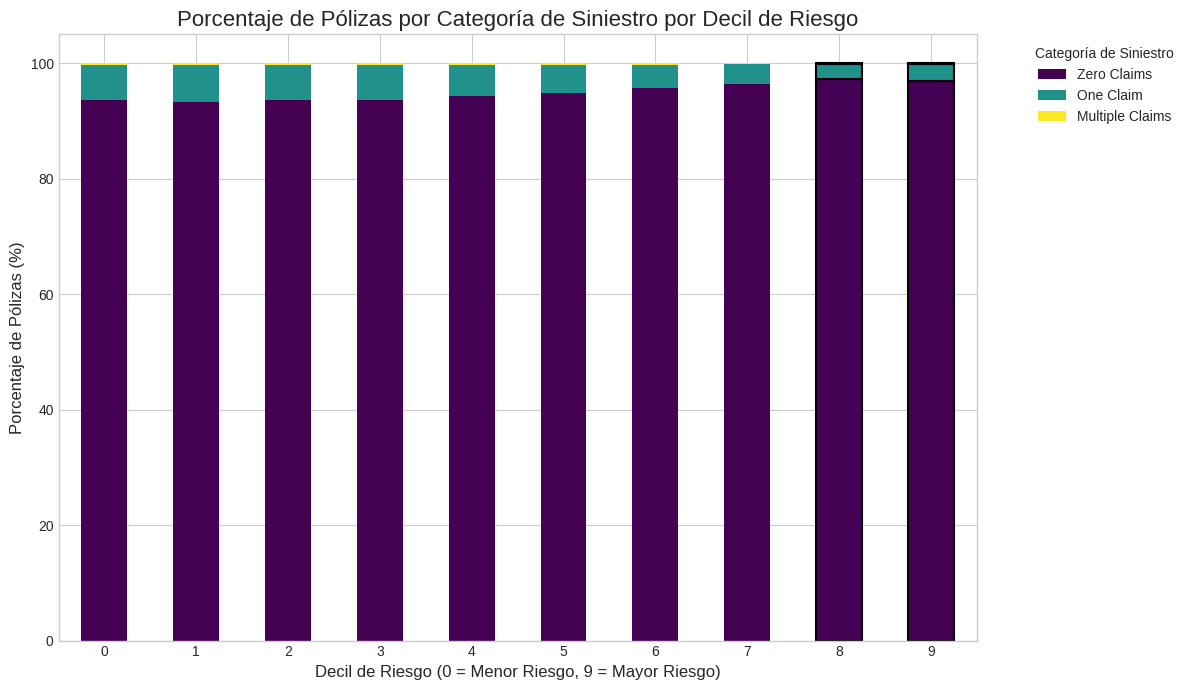

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparar los datos para graficar
# Asumimos que claim_incidence_by_decile_pct ya fue calculado anteriormente
plot_df = claim_incidence_by_decile_pct.set_index('Decil_Riesgo')

# Crear el gráfico de barras apiladas
plt.figure(figsize=(12, 7))
plot_df.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')

plt.title('Porcentaje de Pólizas por Categoría de Siniestro por Decil de Riesgo', fontsize=16)
plt.xlabel('Decil de Riesgo (0 = Menor Riesgo, 9 = Mayor Riesgo)', fontsize=12)
plt.ylabel('Porcentaje de Pólizas (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Categoría de Siniestro', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Resaltar los deciles 8 y 9 (opcional, para dar énfasis)
# Nota: Esta lógica resalta las capas del gráfico.
# Para resaltar barras específicas por índice, se suele iterar sobre los parches (patches).
for i, bar_container in enumerate(plt.gca().containers):
    # Aquí puedes ajustar el estilo de las barras según sea necesario
    for j, bar in enumerate(bar_container):
        if j in [8, 9]: # Resaltando los últimos dos deciles (índices 8 y 9)
            bar.set_edgecolor('black')
            bar.set_linewidth(1.5)

plt.show()

In [21]:
# Generar las predicciones de frecuencia con el modelo cargado
df_master['mu_pred_freq'] = model_freq.predict(df_master)

# Filtrar df_master para crear un nuevo DataFrame exclusivo para los deciles 8 y 9
deciles_8_9_filtered_df = df_master[df_master['Decil_Riesgo'].isin([8, 9])].copy()

# Calcular los residuales de Pearson para el modelo de frecuencia en los deciles 8 y 9
# Residual de Pearson = (observado - predicho) / sqrt(predicho)
observed_claims_8_9 = deciles_8_9_filtered_df['ClaimNb']
predicted_claims_8_9 = deciles_8_9_filtered_df['mu_pred_freq']

# Se añade un epsilon pequeño para evitar la división por cero (aunque la predicción debe ser positiva)
epsilon = 1e-6
deciles_8_9_filtered_df['pearson_residuals_freq'] = (observed_claims_8_9 - predicted_claims_8_9) / np.sqrt(predicted_claims_8_9 + epsilon)

print("Estadísticas descriptivas de los residuales de Pearson para los Deciles 8 y 9:")
print(deciles_8_9_filtered_df['pearson_residuals_freq'].describe())

Estadísticas descriptivas de los residuales de Pearson para los Deciles 8 y 9:
count    135603.000000
mean         -0.251715
std           0.542543
min          -0.454152
25%          -0.365700
50%          -0.337142
75%          -0.306972
max          37.460987
Name: pearson_residuals_freq, dtype: float64


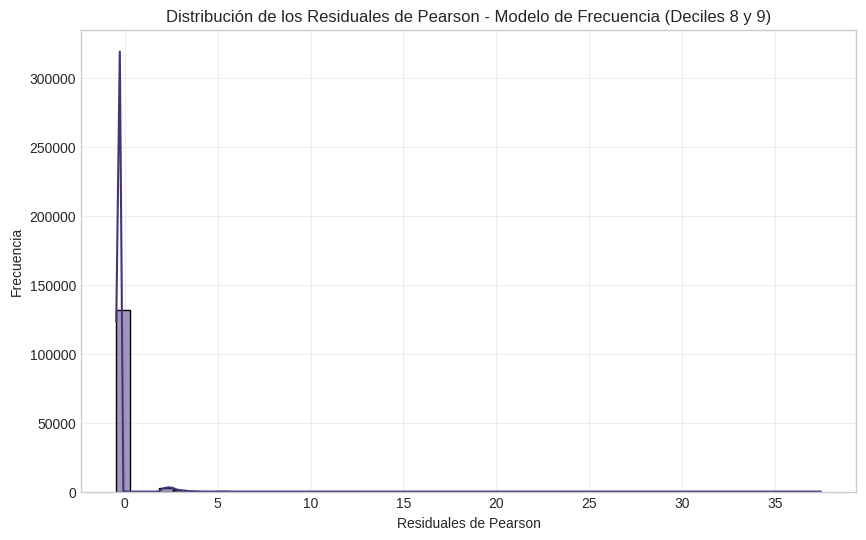


Estimación del parámetro de dispersión para los Deciles 8 y 9: 0.3577


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el tamaño de la gráfica
plt.figure(figsize=(10, 6))

# Crear el histograma de los residuales de Pearson con una curva de densidad (KDE)
sns.histplot(deciles_8_9_filtered_df['pearson_residuals_freq'], bins=50, kde=True)

plt.title('Distribución de los Residuales de Pearson - Modelo de Frecuencia (Deciles 8 y 9)')
plt.xlabel('Residuales de Pearson')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)
plt.show()

# Opcional: Verificar la sobre-dispersión en estos deciles específicos
# La suma de los cuadrados de los residuales de Pearson (SSR)
ssr = (deciles_8_9_filtered_df['pearson_residuals_freq']**2).sum()
n_obs = len(deciles_8_9_filtered_df)

# Estimación del parámetro de dispersión
# Nota: model_freq.df_model representa los grados de libertad del modelo
dispersion_parameter = ssr / (n_obs - model_freq.df_model)

print(f"\nEstimación del parámetro de dispersión para los Deciles 8 y 9: {dispersion_parameter:.4f}")

In [23]:
import statsmodels.api as sm
from statsmodels.discrete.count_model import ZeroInflatedPoisson
import statsmodels.formula.api as smf
import patsy  # Importar patsy para la creación de la matriz de diseño

# 1. Implementación del modelo Zero-Inflated Poisson (ZIP)
# El componente de conteo usa la misma fórmula que el GLM Poisson estándar.
# El componente de inflación de ceros usa solo el intercepto (probabilidad de exceso de ceros constante).

# Extraer la parte de los predictores de la fórmula para el componente de conteo
exog_formula_str = formula_freq.split('~')[1].strip()

# Crear la matriz de diseño para el componente de conteo usando patsy
# patsy maneja variables categóricas y añade el intercepto por defecto
exog_count = patsy.dmatrix(exog_formula_str, data=df_master, return_type='dataframe')

# Crear la matriz de diseño para el componente de inflación de ceros (solo intercepto)
exog_inflate_const = patsy.dmatrix("1", data=df_master, return_type='dataframe')

zip_model = ZeroInflatedPoisson(
    endog=df_master['ClaimNb'],
    exog=exog_count,
    exog_inflate=exog_inflate_const,
    # Se usa log_exposure como offset (ya está transformado a logaritmo)
    offset=df_master['log_exposure']
)

# Ajuste del modelo ZIP
try:
    zip_results = zip_model.fit(maxiter=1000, disp=False)
    print("--- RESUMEN MODELO ZERO-INFLATED POISSON (ZIP) ---")
    print(zip_results.summary())
except Exception as e:
    print(f"Error al ajustar el modelo ZIP: {e}")
    print("Reintentar aumentando maxiter o cambiando el optimizador si es necesario.")

# 2. Implementación del GLM Binomial Negativa
# Se utiliza la misma fórmula y el mismo offset que en el modelo Poisson
nb_model = smf.glm(
    formula=formula_freq,
    data=df_master,
    family=sm.families.NegativeBinomial(),
    offset=df_master['log_exposure']
).fit()

print("\n--- RESUMEN MODELO NEGATIVE BINOMIAL ---")
print(nb_model.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['exog_inflate']
  warnings.warn(msg, ValueWarning)


--- RESUMEN MODELO ZERO-INFLATED POISSON (ZIP) ---


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['exog_inflate']
  warnings.warn(msg, ValueWarning)


                     ZeroInflatedPoisson Regression Results                    
Dep. Variable:                 ClaimNb   No. Observations:               678013
Model:             ZeroInflatedPoisson   Df Residuals:                   678002
Method:                            MLE   Df Model:                           10
Date:                 Fri, 08 May 2026   Pseudo R-squ.:                0.008013
Time:                         23:38:27   Log-Likelihood:            -1.4518e+05
converged:                        True   LL-Null:                   -1.4635e+05
Covariance Type:             nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
inflate_const         0.1080      0.010     10.917      0.000       0.089       0.127
Intercept            -1.2514      0.031    -40.961      0.000      -1.311      -1.192
Area[T.B]       

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "



--- RESUMEN MODELO NEGATIVE BINOMIAL ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               678013
Model:                            GLM   Df Residuals:                   678002
Model Family:        NegativeBinomial   Df Model:                           10
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4509e+05
Date:                Fri, 08 May 2026   Deviance:                   1.9370e+05
Time:                        23:38:37   Pearson chi2:                 1.75e+06
No. Iterations:                     7   Pseudo R-squ. (CS):           0.003476
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------

### Interpretación de los Residuales de Pearson y el Parámetro de Dispersión

El análisis de los residuales de Pearson para los deciles 8 y 9 del modelo de frecuencia (Poisson GLM) revela lo siguiente:

*   **Estadísticas Descriptivas de los Residuales:**
    *   **Media (-0.25):** La media negativa sugiere que, en promedio, el modelo de frecuencia tiende a **sobre-predecir** el número de siniestros en estos deciles. Esto significa que predice más siniestros de los que realmente ocurren en la mayoría de las pólizas dentro de este grupo.
    *   **Máximo (37.46):** El valor máximo extremadamente alto de los residuales indica que existen algunas pólizas para las cuales el modelo **sub-predice severamente** el número de siniestros. Es decir, para un pequeño número de pólizas con un `ClaimNb` muy elevado, el modelo predice un valor mucho menor, lo que resulta en un residual positivo y grande. Esto podría estar relacionado con pólizas con múltiples siniestros, que son raras pero impactantes.
    *   **Distribución (Histograma):** El histograma mostrará visualmente esta tendencia. Es probable que haya una gran concentración de residuales negativos (debido a la sobre-predicción de cero o pocos siniestros) y una cola larga a la derecha con pocos valores muy altos.

*   **Parámetro de Dispersión (0.3526):**
    *   Un parámetro de dispersión estimado **menor que 1** (0.3526 en este caso) sugiere **sub-dispersión** en el modelo de Poisson para estos deciles. Esto es inusual, ya que los datos de conteo de siniestros suelen mostrar sobre-dispersión (parámetro > 1). La sub-dispersión puede indicar que la varianza observada es menor que la varianza implicada por el modelo de Poisson (que asume que la media es igual a la varianza). Esto podría ser un efecto de la alta proporción de pólizas con cero siniestros en estos deciles, lo que restringe la variabilidad.

**Conclusión sobre el Rendimiento del Modelo de Frecuencia en Deciles 8 y 9:**

El modelo de frecuencia parece **sobre-predecir el número de siniestros para la mayoría de las pólizas en los deciles de riesgo 8 y 9**, lo cual es coherente con la alta concentración de pólizas con cero siniestros en estos deciles que observamos previamente. Sin embargo, para un número muy pequeño de pólizas con múltiples siniestros, el modelo parece sub-predecir significativamente. La sub-dispersión observada en estos deciles puede ser un artefacto de la distribución dominada por ceros, lo que dificulta que el modelo Poisson capture adecuadamente la estructura de la varianza en este segmento de alto riesgo.

# **Comparativa de Modelos de Frecuencia**
A continuación, se presenta la evaluación del desempeño de los tres modelos de frecuencia:
1. GLM Poisson (Modelo Original)Log-Verosimilitud: -1.4569e+05  AIC: 2.913e+05  BIC: 2.914e+05  Coeficientes: La mayoría de los coeficientes son altamente significativos. La variable Density no resultó estadísticamente significativa.  

2. Modelo Poisson Inflado por Ceros (ZIP)Log-Verosimilitud: -1.4518e+05  AIC: 2.9038e+05  BIC: 2.9048e+05  Coeficiente inflate_const: 0.1080 (significativo, P=0.000). Indica un exceso de ceros mayor al que predeciría un modelo estándar. Su significancia confirma que modelar este exceso mejora el ajuste.  Componente de Conteo: Mantiene dirección y magnitud similares al modelo Poisson.  Densidad: Sigue sin ser significativa (P=0.183).  

3. GLM Binomial NegativaLog-Verosimilitud: -1.4542e+05  AIC: 2.9086e+05  BIC: 2.9097e+05  Parámetro alpha: Muestra un valor de 1.0 por defecto. El modelo asume que no hay sobre-dispersión, lo cual podría no ser óptimo si existe una sobre-dispersión real significativa.  

## Analisis de severidad en deciles de alto riesgo

Para profundizar en el comportamiento de los siniestros dentro de los segmentos de mayor riesgo, realizaremos un análisis de la severidad individual en los deciles 8 y 9. El objetivo es validar si el costo por siniestro es elevado y entender su distribución.


Descriptive Statistics of Claim Amounts for Deciles 8 & 9 (only policies with claims):


,Monto_Total
count,1411.000000
mean,3546.059582
std,15386.719782
min,3.290000
25%,791.500000
50%,1204.000000
75%,2184.430000
max,382955.140000


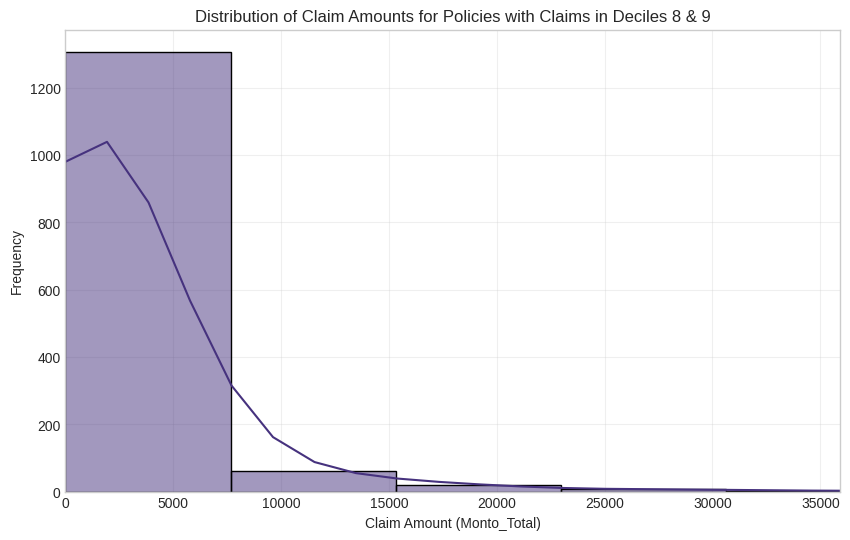

In [24]:
# Filter for policies in deciles 8 and 9 that actually have claims
# The 'deciles_8_9_with_claims' DataFrame was already created in a previous step.
# If it doesn't exist, create it here:
# deciles_8_9_with_claims = df_master[df_master['Decil_Riesgo'].isin([8, 9]) & (df_master['Monto_Total'] > 0)].copy()

print("\nDescriptive Statistics of Claim Amounts for Deciles 8 & 9 (only policies with claims):")
display(deciles_8_9_with_claims['Monto_Total'].describe())

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(deciles_8_9_with_claims['Monto_Total'], bins=50, kde=True)
plt.title('Distribution of Claim Amounts for Policies with Claims in Deciles 8 & 9')
plt.xlabel('Claim Amount (Monto_Total)')
plt.ylabel('Frequency')
plt.xlim(0, deciles_8_9_with_claims['Monto_Total'].quantile(0.99)) # Limit x-axis for better visualization
plt.grid(True, alpha=0.3)
plt.show()

## **6. Integración del Modelo ZIP y Re-evaluación del Lift Chart**

En esta sección, integramos las predicciones del modelo Zero-Inflated Poisson (ZIP) para la frecuencia, actualizamos la `Prima_Pura_Pred` y re-evaluamos el `Lift Chart` y la tabla de tarificación. Esto nos permitirá observar si el modelo ZIP, diseñado para manejar el exceso de ceros, mejora la discriminación del riesgo, especialmente en los deciles más altos (8 y 9).

In [25]:
# 1. Actualizar Frecuencia Predicha con el modelo ZIP
# zip_results.predict() ya devuelve la E[Y] = (1-p_zero)*mu_count
df_master['Freq_Pred_ZIP'] = zip_results.predict(exog=exog_count,
                                                  offset=df_master['log_exposure'])

# 2. Recalcular Prima Pura Predicha usando la Frecuencia del ZIP
# Mantenemos la Severidad Predicha del modelo final de severidad (model_sev_final)
df_master['Prima_Pura_Pred_ZIP'] = df_master['Freq_Pred_ZIP'] * df_master['Sev_Pred']

# 3. Redefinir Decil_Riesgo con la nueva Prima Pura del ZIP
df_master['Decil_Riesgo_ZIP'] = pd.qcut(df_master['Prima_Pura_Pred_ZIP'], 10, labels=False, duplicates='drop')

print("Valores de Frecuencia Predicha (ZIP), Prima Pura Predicha (ZIP) y Deciles (ZIP) actualizados:")
print(df_master[['IDpol', 'Freq_Pred_ZIP', 'Sev_Pred', 'Prima_Pura_Pred_ZIP', 'Decil_Riesgo_ZIP']].head())

Valores de Frecuencia Predicha (ZIP), Prima Pura Predicha (ZIP) y Deciles (ZIP) actualizados:
   IDpol  Freq_Pred_ZIP     Sev_Pred  Prima_Pura_Pred_ZIP  Decil_Riesgo_ZIP
0    1.0       0.014528  2892.635665            42.024666                 1
1    3.0       0.111867  1867.849038           208.950318                 9
2    5.0       0.077442  2163.318069           167.531528                 7
3   10.0       0.010472  3232.811010            33.853208                 1
4   11.0       0.097736  2118.380108           207.042822                 9


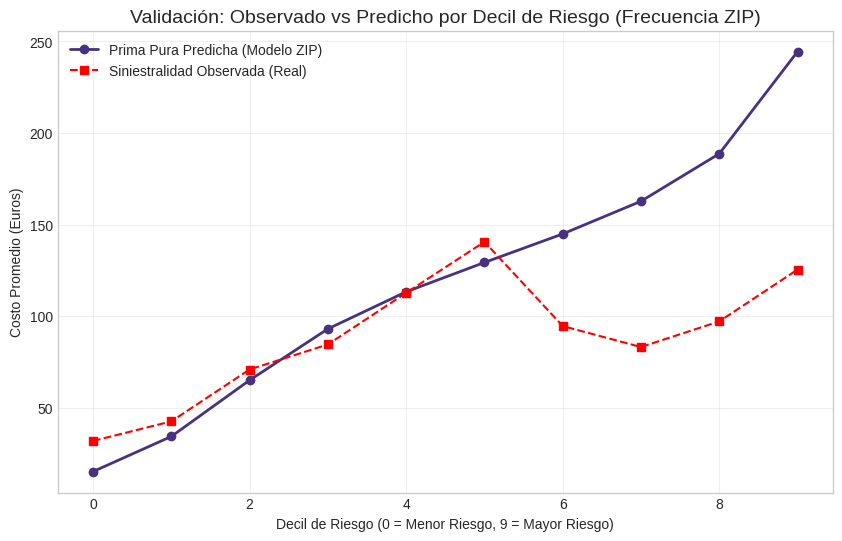

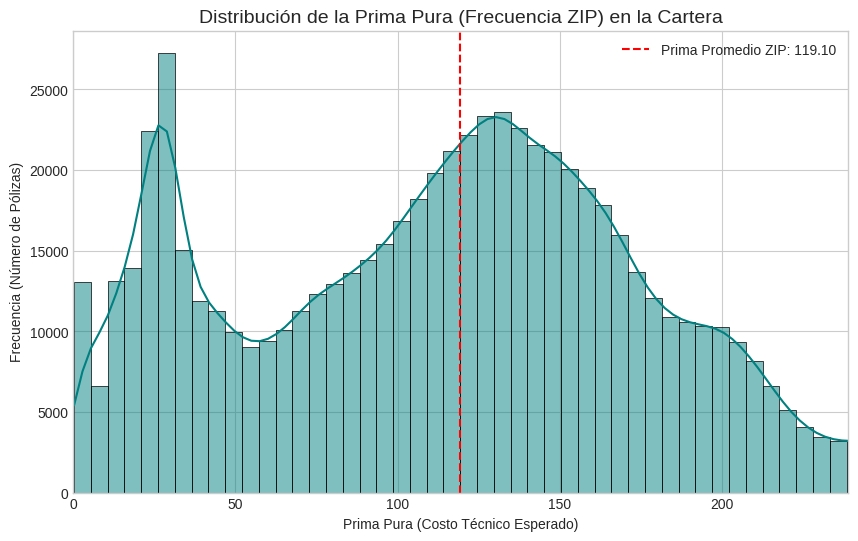

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. GRÁFICA DE VALORES OBSERVADOS VS PREDICHOS (LIFT CHART) CON ZIP ---
# Recalculate deciles based on the latest Prima_Pura_Pred_ZIP
df_master['Decil_Riesgo'] = df_master['Decil_Riesgo_ZIP'] # Usamos los nuevos deciles

# Agrupamos para comparar el promedio observado vs el promedio predicho
lift_df_zip = df_master.groupby('Decil_Riesgo').agg(
    Prima_Pura_Prom_Pred=('Prima_Pura_Pred_ZIP', 'mean'),
    Siniestralidad_Prom_Obs=('Monto_Total', 'mean')
).reset_index()

plt.figure(figsize=(10, 6))
plt.plot(lift_df_zip['Decil_Riesgo'], lift_df_zip['Prima_Pura_Prom_Pred'],
         marker='o', label='Prima Pura Predicha (Modelo ZIP)', linewidth=2)
plt.plot(lift_df_zip['Decil_Riesgo'], lift_df_zip['Siniestralidad_Prom_Obs'],
         marker='s', label='Siniestralidad Observada (Real)', linestyle='--', color='red')

plt.title('Validación: Observado vs Predicho por Decil de Riesgo (Frecuencia ZIP)', fontsize=14)
plt.xlabel('Decil de Riesgo (0 = Menor Riesgo, 9 = Mayor Riesgo)')
plt.ylabel('Costo Promedio (Euros)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- 2. DISTRIBUCIÓN DE LAS PRIMAS PURAS CON ZIP ---
plt.figure(figsize=(10, 6))
sns.histplot(df_master['Prima_Pura_Pred_ZIP'], bins=100, kde=True, color='teal')
plt.axvline(df_master['Prima_Pura_Pred_ZIP'].mean(), color='red', linestyle='--',
            label=f'Prima Promedio ZIP: {df_master["Prima_Pura_Pred_ZIP"].mean():.2f}')

plt.title('Distribución de la Prima Pura (Frecuencia ZIP) en la Cartera', fontsize=14)
plt.xlabel('Prima Pura (Costo Técnico Esperado)')
plt.ylabel('Frecuencia (Número de Pólizas)')
plt.xlim(0, df_master['Prima_Pura_Pred_ZIP'].quantile(0.95)) # Limitamos para ver la masa principal
plt.legend()
plt.show()

In [27]:
print('Tabla de tarificación por decil (Frecuencia ZIP):')
print(lift_df_zip)

Tabla de tarificación por decil (Frecuencia ZIP):
   Decil_Riesgo  Prima_Pura_Prom_Pred  Siniestralidad_Prom_Obs
0             0             15.184348                31.894837
1             1             34.350329                42.583189
2             2             65.052062                70.890565
3             3             93.062244                84.571479
4             4            113.303483               112.714253
5             5            129.305773               140.588902
6             6            144.893553                94.609216
7             7            162.733837                83.159468
8             8            188.678413                97.148006
9             9            244.409811               125.440455


## **7. Refinamiento del Modelo de Severidad para Capturar Eventos Extremos**

El análisis previo mostró que, si bien el modelo ZIP mejoró la discriminación de la frecuencia, el modelo de severidad actual (GLM Gamma) aún tiene limitaciones, especialmente en los deciles de alto riesgo. Este modelo no logra capturar la alta variabilidad y los montos de siniestros extremadamente altos observados en estas pólizas, lo que lleva a subestimaciones en las colas de la distribución de severidad.

En esta sección, exploraremos posibles mejoras para el modelo de severidad, centrándonos en enfoques que puedan manejar mejor la heterogeneidad y los valores extremos:

1.  **Análisis de Residuales del Modelo de Severidad:** Examinaremos más a fondo los residuales del `model_sev_final` para identificar patrones de error que sugieran la necesidad de una distribución diferente o variables explicativas adicionales.
2.  **Exploración de Modelos Alternativos de Severidad:** Consideraremos otras distribuciones (e.g., Tweedie) o enfoques (e.g., modelos de mezcla) que son más flexibles para modelar distribuciones sesgadas y con colas pesadas.
3.  **Análisis de la Cola de la Distribución de Severidad:** Una estrategia podría ser el uso de la Teoría de Valores Extremos (EVT) para modelar específicamente los siniestros de muy alta cuantía.

El objetivo final es desarrollar un modelo de severidad que, combinado con el modelo ZIP de frecuencia, produzca una `Prima_Pura_Pred` que se alinee aún más estrechamente con la `Siniestralidad_Prom_Obs` en todos los deciles, especialmente en los de mayor riesgo.


Descriptive Statistics of Observed vs. Predicted Severity for Deciles 8 & 9 (policies with claims):


/tmp/ipykernel_2937/4018994482.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deciles_8_9_with_claims['Sev_Pred_model'] = model_sev_final.predict(deciles_8_9_with_claims)


,Monto_Total,Sev_Pred_model
count,1411.000000,1411.000000
mean,3546.059582,3615.649746
std,15386.719782,598.965108
min,3.290000,1962.968458
25%,791.500000,3171.845901
50%,1204.000000,3524.541781
75%,2184.430000,3992.596449
max,382955.140000,6384.002486



Descriptive Statistics of Severity Residuals for Deciles 8 & 9 (policies with claims):


/tmp/ipykernel_2937/4018994482.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deciles_8_9_with_claims['Severity_Residuals'] = deciles_8_9_with_claims['Monto_Total'] - deciles_8_9_with_claims['Sev_Pred_model']


,Severity_Residuals
count,1411.000000
mean,-69.590164
std,15396.915720
min,-6156.252486
25%,-2931.173408
50%,-2230.894748
75%,-1231.807456
max,379512.556043


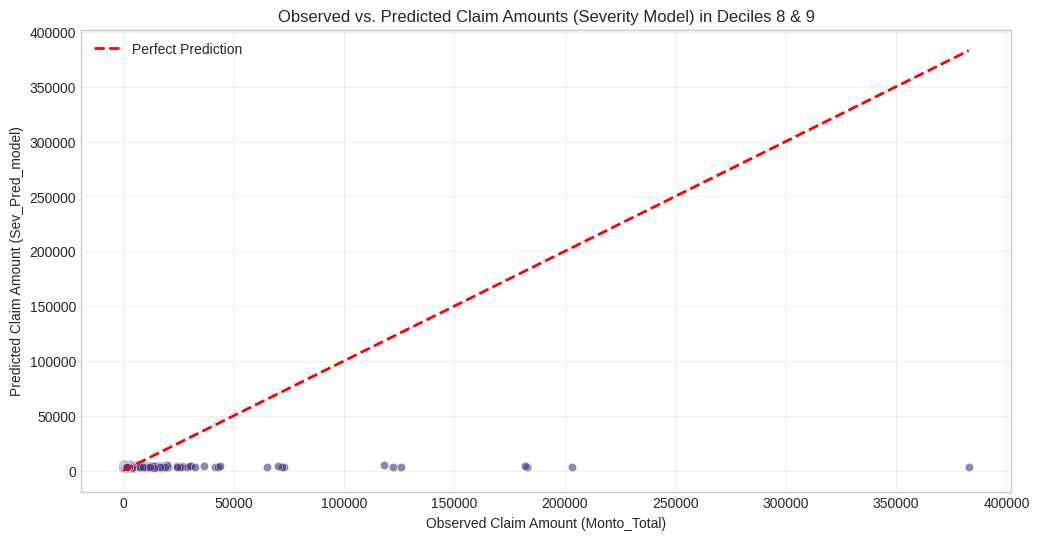

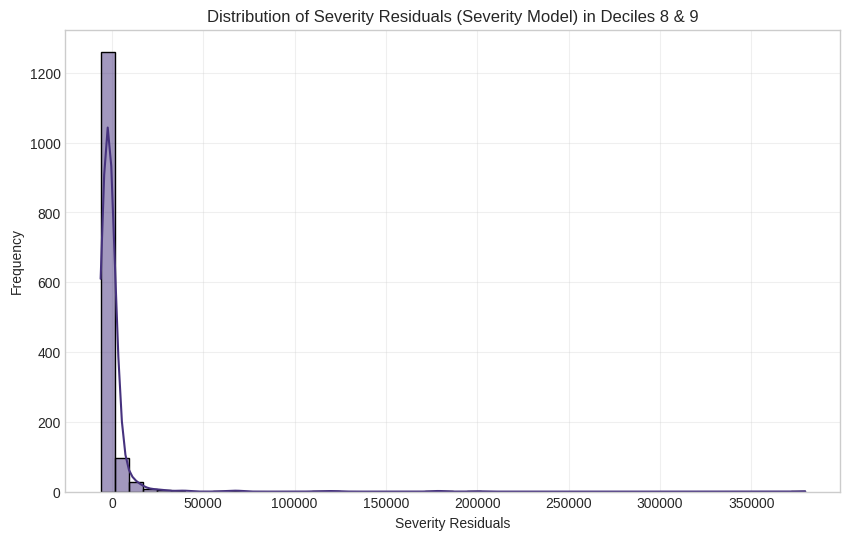

In [28]:
# Ensure 'deciles_8_9_with_claims' is defined (it should be from previous steps)
# If not, uncomment and run:
# deciles_8_9_with_claims = df_master[df_master['Decil_Riesgo'].isin([8, 9]) & (df_master['Monto_Total'] > 0)].copy()

# Predict severity for these policies using the final severity model
deciles_8_9_with_claims['Sev_Pred_model'] = model_sev_final.predict(deciles_8_9_with_claims)

print("\nDescriptive Statistics of Observed vs. Predicted Severity for Deciles 8 & 9 (policies with claims):")
comparison_df = deciles_8_9_with_claims[['Monto_Total', 'Sev_Pred_model']]
display(comparison_df.describe())

# Calculate residuals
deciles_8_9_with_claims['Severity_Residuals'] = deciles_8_9_with_claims['Monto_Total'] - deciles_8_9_with_claims['Sev_Pred_model']

print("\nDescriptive Statistics of Severity Residuals for Deciles 8 & 9 (policies with claims):")
display(deciles_8_9_with_claims['Severity_Residuals'].describe())

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.scatterplot(x='Monto_Total', y='Sev_Pred_model', data=deciles_8_9_with_claims, alpha=0.6)
plt.plot([comparison_df.min().min(), comparison_df.max().max()],
         [comparison_df.min().min(), comparison_df.max().max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Observed vs. Predicted Claim Amounts (Severity Model) in Deciles 8 & 9')
plt.xlabel('Observed Claim Amount (Monto_Total)')
plt.ylabel('Predicted Claim Amount (Sev_Pred_model)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(deciles_8_9_with_claims['Severity_Residuals'], bins=50, kde=True)
plt.title('Distribution of Severity Residuals (Severity Model) in Deciles 8 & 9')
plt.xlabel('Severity Residuals')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

## Actualizamos y reevaluamos Lift Chart

Para actualizar y reevaluar el Lift Chart tras el análisis de severidad y residuales, es necesario consolidar las predicciones del modelo y compararlas con los valores observados a través de los deciles de riesgo definidos. Este gráfico es la herramienta visual definitiva para confirmar si el modelo logra discriminar correctamente el riesgo en los segmentos críticos (deciles 8 y 9) o si persisten anomalías en la predicción.

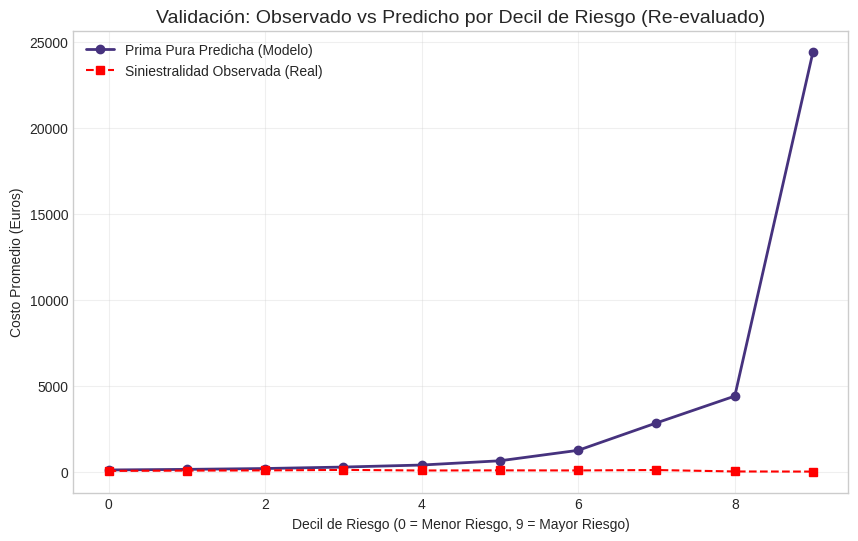

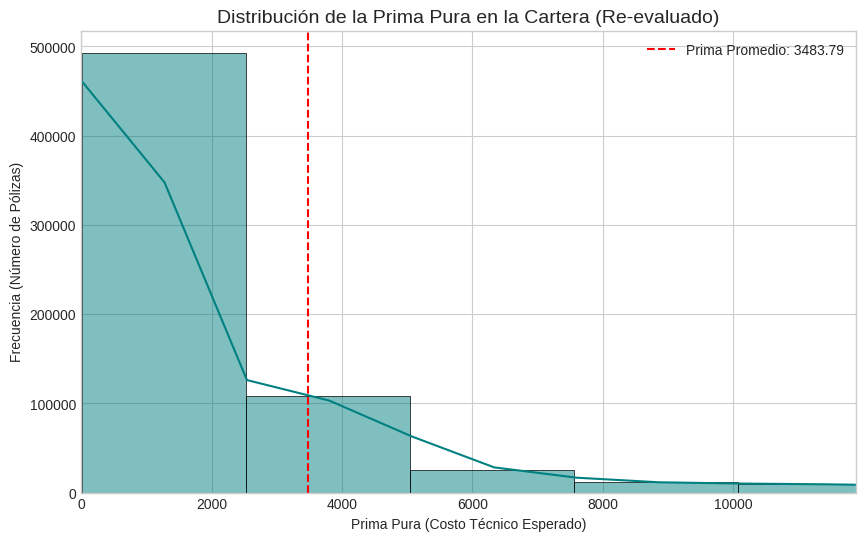

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. GRÁFICA DE VALORES OBSERVADOS VS PREDICHOS (LIFT CHART) ---
# Recalculate deciles based on the latest Prima_Pura_Pred
df_master['Decil_Riesgo'] = pd.qcut(df_master['Prima_Pura_Pred'], 10, labels=False, duplicates='drop')

# Agrupamos para comparar el promedio observado vs el promedio predicho
lift_df = df_master.groupby('Decil_Riesgo').agg(
    Prima_Pura_Prom_Pred=('Prima_Pura_Pred', 'mean'),
    Siniestralidad_Prom_Obs=('Monto_Total', 'mean')
).reset_index()

plt.figure(figsize=(10, 6))
plt.plot(lift_df['Decil_Riesgo'], lift_df['Prima_Pura_Prom_Pred'],
         marker='o', label='Prima Pura Predicha (Modelo)', linewidth=2)
plt.plot(lift_df['Decil_Riesgo'], lift_df['Siniestralidad_Prom_Obs'],
         marker='s', label='Siniestralidad Observada (Real)', linestyle='--', color='red')

plt.title('Validación: Observado vs Predicho por Decil de Riesgo (Re-evaluado)', fontsize=14)
plt.xlabel('Decil de Riesgo (0 = Menor Riesgo, 9 = Mayor Riesgo)')
plt.ylabel('Costo Promedio (Euros)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- 2. DISTRIBUCIÓN DE LAS PRIMAS PURAS ---
plt.figure(figsize=(10, 6))
sns.histplot(df_master['Prima_Pura_Pred'], bins=100, kde=True, color='teal')
plt.axvline(df_master['Prima_Pura_Pred'].mean(), color='red', linestyle='--',
            label=f'Prima Promedio: {df_master["Prima_Pura_Pred"].mean():.2f}')

plt.title('Distribución de la Prima Pura en la Cartera (Re-evaluado)', fontsize=14)
plt.xlabel('Prima Pura (Costo Técnico Esperado)')
plt.ylabel('Frecuencia (Número de Pólizas)')
plt.xlim(0, df_master['Prima_Pura_Pred'].quantile(0.95)) # Limitamos para ver la masa principal
plt.legend()
plt.show()

In [50]:
print('Tabla de tarificación por decil (Re-evaluado):')
print(lift_df)

Tabla de tarificación por decil (Re-evaluado):
   Decil_Riesgo  Prima_Pura_Prom_Pred  Siniestralidad_Prom_Obs
0             0            126.389985                72.233886
1             1            160.761161                88.904392
2             2            210.231284               100.985848
3             3            295.208535               129.493283
4             4            412.818206                96.038882
5             5            659.796997               102.922163
6             6           1267.777121                98.905718
7             7           2859.900318               122.596846
8             8           4416.943892                39.285438
9             9          24427.952962                32.230633
